# Telecom Customer Churn Prediction
In this analysis, we predict customer churn using machine learning models to assist in improving retention strategies for telecom companies.

The dataset consists of various features related to customer usage patterns, contract type, and payment method, which are used to predict whether a customer will churn.

We apply several machine learning algorithms such as **Logistic Regression**, **Random Forest**, and **Gradient Boosting** to evaluate their performance in predicting customer churn.

In [ ]:
import pandas as pd

# Load the dataset
file_path = 'CustomerChurnData.csv'
data = pd.read_csv(file_path)

# Display the first few rows to understand the dataset
data.head()

# drop the CustomerID column as its not useful
data = data.drop(columns=['Customer ID'])

## Data Preprocessing

The dataset required several preprocessing steps before applying machine learning models:

- Handling **missing values**.
- **Encoding categorical variables** such as gender, contract type, and payment method. (Few where handles in Alteryx, the missed one are handles here)
- **Scaling numerical features** for improved model performance.
- Splitting the data into **training** and **test** sets.

These steps are crucial to ensure the models can learn efficiently and make accurate predictions.


In [ ]:
# Check for missing values
data.isnull().sum()

Churn Label                             0
Account Length (in months)              0
Local Calls                             0
Local Mins                              0
Intl Calls                              0
Intl Mins                               0
Intl Active                             0
Intl Plan                               0
Extra International Charges             0
Customer Service Calls                  0
Avg Monthly GB Download                 0
Unlimited Data Plan                     0
Extra Data Charges                      0
State                                   0
Phone Number                            0
Gender                                  0
Age                                     0
Under 30                                0
Senior                                  0
Group                                   0
Number of Customers in Group            0
Device Protection & Online Backup       0
Contract Type                           0
Payment Method                    

In [ ]:
# drop the Churn Category and Churn Reasoncolumn as its not useful
data = data.drop(columns=['Churn Category','Churn Reason','Churn Label','Intl Active','Intl Plan','Phone Number','Gender','Senior','Group','Device Protection & Online Backup', 'Contract Type', 'Payment Method','State'])

In [ ]:
# Find columns with string (object) data type
string_columns = data.select_dtypes(include=['object']).columns

# Display the string columns
print("Columns with strings:", string_columns)


Columns with strings: Index(['Unlimited Data Plan', 'Under 30', 'Total_Call_Minutes'], dtype='object')


In [ ]:
# First, let's inspect the 'Total_Call_Minutes' column to check for non-numeric values
data['Total_Call_Minutes'].head()

# If the column contains any non-numeric characters (like commas, etc.), clean them
# Remove any non-numeric characters (e.g., commas, spaces, or other symbols) using regex
data['Total_Call_Minutes'] = data['Total_Call_Minutes'].replace({',': '', ' ': ''}, regex=True)

# Convert the column to numeric, forcing errors to NaN (if any invalid values exist)
data['Total_Call_Minutes'] = pd.to_numeric(data['Total_Call_Minutes'], errors='coerce')

# Check for missing or invalid values (if there are NaN values, we'll handle them next)
data['Total_Call_Minutes'].isnull().sum()

# Optionally, fill missing values with a default (e.g., 0) or drop rows with missing values
data['Total_Call_Minutes'].fillna(0, inplace=True)

# Verify the changes
data['Total_Call_Minutes'].head()


C:\Users\deepi\AppData\Local\Temp\ipykernel_25704\1076006448.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Total_Call_Minutes'].fillna(0, inplace=True)


0     80.000
1    431.300
2    217.600
3    111.671
4      0.000
Name: Total_Call_Minutes, dtype: float64

In [ ]:
# Handle categorical variables (e.g., using Label Encoding for simplicity)
from sklearn.preprocessing import LabelEncoder

# Assuming 'Churn' is the target variable and other columns are features
label_encoder = LabelEncoder()
,
# Convert other categorical columns if any (like 'Senior', 'Under 30')
data['Under 30'] = label_encoder.fit_transform(data['Under 30'])
data['Unlimited Data Plan'] = label_encoder.fit_transform(data['Unlimited Data Plan'])


In [ ]:

# Split into features and target
X = data.drop(columns=['Churn'])
y = data['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Display the first few rows to understand the dataset
X_train.head()



,Account Length (in months),Local Calls,Local Mins,Intl Calls,Intl Mins,Extra International Charges,Customer Service Calls,Avg Monthly GB Download,Unlimited Data Plan,Extra Data Charges,...,Intl_Plan_Flag,Device_Protection_Flag,Contract_Month_to_Month,Contract_One_Year,Contract_Two_Yeat,Payment_Direct_Debit,Payment_Paper_Check,Total_Call_Minutes,Engagement_Score,Avg_Monthly_Spend
879,66,697,1062.5,0.0,0.0,0.0,0,3,1,0,...,0,0,0,0,1,0,0,1062.5000,10.560606,0.590909
2907,61,329,982.2,244.0,896.7,448.4,0,8,1,0,...,0,0,0,0,1,0,0,0.0000,5.393443,0.508197
1839,27,133,371.1,108.0,324.0,0.0,0,0,0,0,...,1,0,0,1,0,0,0,371.1324,4.925926,0.444444
5025,44,288,614.0,0.0,0.0,0.0,1,10,1,0,...,0,0,1,0,0,1,0,6140.0000,6.545455,0.590909
2481,22,46,132.4,88.0,200.2,0.0,0,9,1,0,...,1,0,1,0,0,1,0,0.0000,2.090909,1.318182


In [ ]:
# Ensure all columns are numeric
print(X_train.dtypes)

Account Length (in months)        int64
Local Calls                       int64
Local Mins                      float64
Intl Calls                      float64
Intl Mins                       float64
Extra International Charges     float64
Customer Service Calls            int64
Avg Monthly GB Download           int64
Unlimited Data Plan               int32
Extra Data Charges                int64
Age                               int64
Under 30                          int32
Number of Customers in Group      int64
Monthly Charge                    int64
Total Charges                     int64
Senior_Flag                       int64
Group_Flag                        int64
Intl_Active_Flag                  int64
Intl_Plan_Flag                    int64
Device_Protection_Flag            int64
Contract_Month_to_Month           int64
Contract_One_Year                 int64
Contract_Two_Yeat                 int64
Payment_Direct_Debit              int64
Payment_Paper_Check               int64


In [ ]:
# Ensure all columns are numeric
print(y_train.dtypes)

int64


## Model Building

We used three different machine learning models to predict customer churn:

1. **Logistic Regression**: A simple linear model suitable for binary classification tasks.
2. **Random Forest**: An ensemble model that combines the output of multiple decision trees for better accuracy and reduced overfitting.
3. **Gradient Boosting**: Another powerful ensemble method that builds models sequentially and focuses on correcting the errors of previous models.

Each model was trained on the preprocessed data and evaluated using accuracy, precision, recall, F1-score, and AUC-ROC.


##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Ensure X_train and X_test are DataFrames to keep feature names
scaler = StandardScaler()

# Fit and transform the training data, then transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled data back to DataFrames with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Train the Logistic Regression model using the scaled DataFrame
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled_df, y_train)

# Predict using the scaled DataFrame (retaining feature names)
y_pred = model.predict(X_test_scaled_df)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Classification report gives precision, recall, and F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.2743
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.04      0.07       986
           1       0.26      0.94      0.41       352

    accuracy                           0.27      1338
   macro avg       0.45      0.49      0.24      1338
weighted avg       0.54      0.27      0.16      1338

Confusion Matrix:
[[ 35 951]
 [ 20 332]]


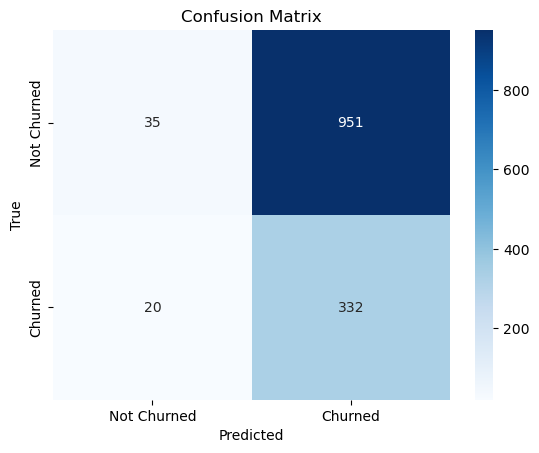

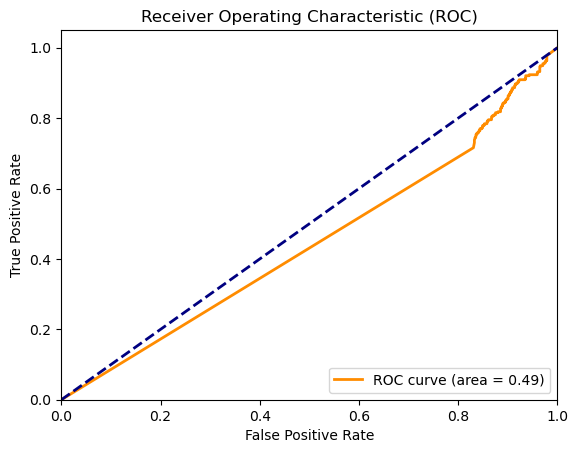

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
roc_auc = roc_auc_score(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


## Model Evaluation
The Logistic Regression model provided a baseline for performance, with an accuracy of **27.43%**. However, it showed poor performance in predicting **non-churned customers**, with very low recall for that class.




## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions and evaluate
rf_y_pred = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the model
accuracy = accuracy_score(y_test, rf_y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Classification report gives precision, recall, and F1-score
print("Classification Report:")
print(classification_report(y_test, rf_y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))


Accuracy: 0.8969
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       986
           1       0.86      0.72      0.79       352

    accuracy                           0.90      1338
   macro avg       0.89      0.84      0.86      1338
weighted avg       0.90      0.90      0.89      1338

Confusion Matrix:
[[946  40]
 [ 98 254]]


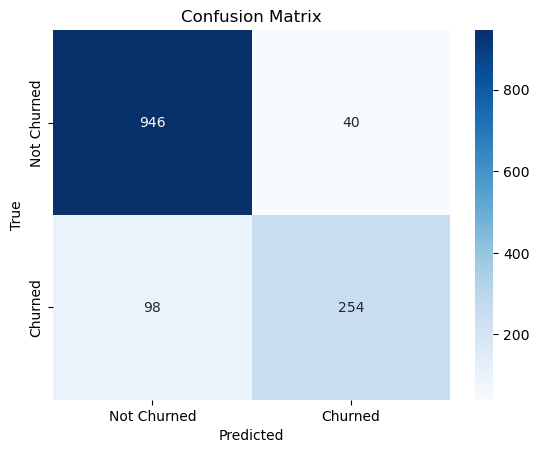

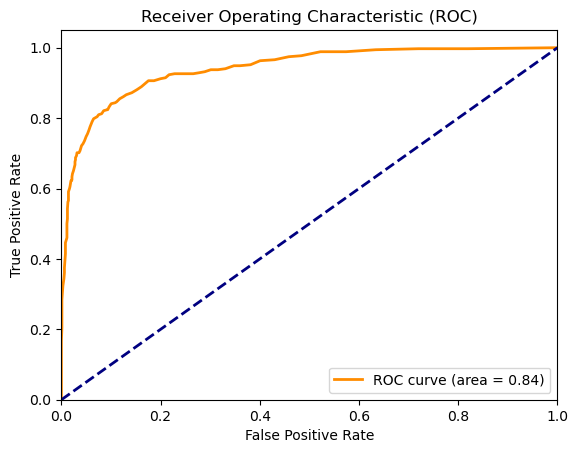

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, rf_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc = roc_auc_score(y_test, rf_y_pred)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()



The Random Forest model performed significantly better, achieving **89.69% accuracy**, with good precision and recall for both churned and non-churned customers. This model demonstrated a **balance between recall and precision**, though there is room for improvement in predicting churned customers.



## Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Instantiate and train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions and evaluate
gb_y_pred = gb_model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the model
accuracy = accuracy_score(y_test, gb_y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Classification report gives precision, recall, and F1-score
print("Classification Report:")
print(classification_report(y_test, gb_y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_y_pred))


Accuracy: 0.9043
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       986
           1       0.87      0.75      0.80       352

    accuracy                           0.90      1338
   macro avg       0.89      0.85      0.87      1338
weighted avg       0.90      0.90      0.90      1338

Confusion Matrix:
[[947  39]
 [ 89 263]]


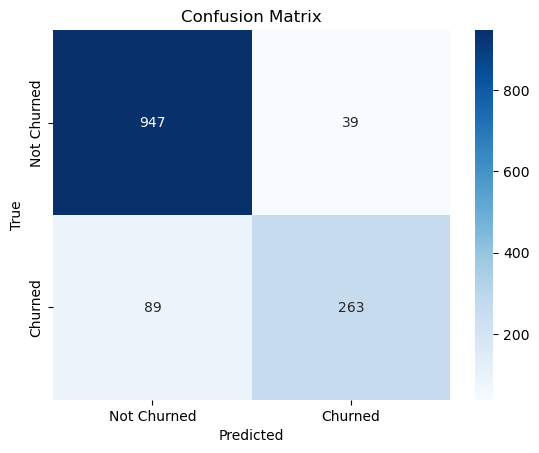

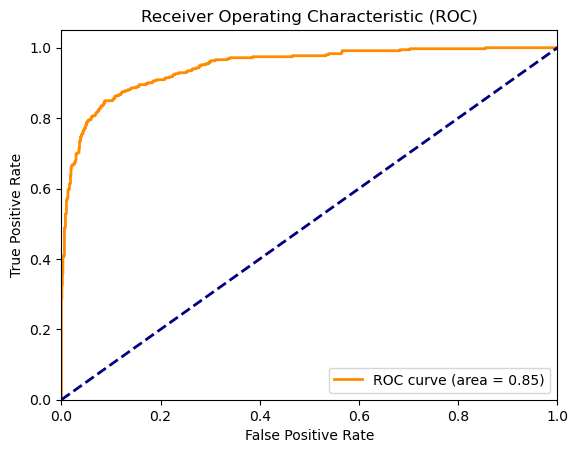

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, gb_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, gb_model.predict_proba(X_test)[:, 1])
roc_auc = roc_auc_score(y_test, gb_y_pred)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()


The Gradient Boosting model provided the best performance, with an accuracy of **90.43%**. It showed excellent performance in predicting both **churned** and **non-churned** customers, achieving the highest **recall** for churned customers (**0.75**) compared to Random Forest.

Overall, **Gradient Boosting** was the most effective model for this task, but all models performed significantly better than Logistic Regression.



## Confusion Matrix and ROC Curve

We also visualized the **confusion matrix** and **ROC curve** for each model to evaluate their classification performance.

- **Confusion Matrix**: Shows the number of true positives, false positives, true negatives, and false negatives for each model.
- **ROC Curve**: A graphical representation of the trade-off between true positive rate (recall) and false positive rate, with the **AUC** score summarizing the model's ability to distinguish between churned and non-churned customers.



## Key Findings

1. **Logistic Regression** showed a **poor** performance with a very low recall for **non-churned** customers.
2. **Random Forest** and **Gradient Boosting** performed significantly better, with **high accuracy** and **balanced performance** between precision and recall.
3. **Gradient Boosting** outperformed **Random Forest**, especially in predicting **churned customers**, where it achieved the highest recall score (**0.75**).


Model's Performance:
The Gradient Boosting model has high accuracy (90.43%), indicating it is effective at predicting churn.

The high precision (0.91) and recall (0.96) for non-churned customers indicate that the model is particularly good at identifying customers who won't churn.

Churned customers have a recall of 0.75, meaning the model does miss some churned customers, but this is still a good result, especially considering the high accuracy overall.

Retention Focus:

The model is highly effective in identifying non-churned customers, so the business can use this information to prioritize customers who are already engaged and focus efforts on retaining those who are at lower risk of churning.

For customers identified as churned, although the recall is slightly lower (0.75), this still means that a significant portion of churned customers can be targeted for retention efforts.

Targeted Retention Programs:

For churned customers, you can implement targeted retention campaigns. You might consider offering loyalty rewards, special offers, or discounts to these customers to increase retention.

Focus on up-selling or cross-selling services to non-churned customers to keep them engaged and reduce the chances of them churning in the future.